In [ ]:
import os
os.environ["KAGGLE USERNAME"] = "mohammedhasan11234"
os.environ["KAGGLE KEY"] = "KGAT_12eeb694e27fa5289f371e88c156998a"

In [ ]:
!kaggle datasets download -d "vencerlanz09/pharmaceutical-drugs-and-vitamins-synthetic-images"

Dataset URL: https://www.kaggle.com/datasets/vencerlanz09/pharmaceutical-drugs-and-vitamins-synthetic-images
License(s): CC-BY-SA-3.0
pharmaceutical-drugs-and-vitamins-synthetic-images.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip "/content/pharmaceutical-drugs-and-vitamins-synthetic-images.zip"

Archive:  /content/pharmaceutical-drugs-and-vitamins-synthetic-images.zip
replace Drug Vision/Data Combined/Alaxan/00000000.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [ ]:
dataset_path = "/content/Drug Vision/Data Combined"
print(os.listdir(dataset_path))

['Decolgen', 'Neozep', 'Kremil S', 'DayZinc', 'Fish Oil', 'Biogesic', 'Bactidol', 'Medicol', 'Alaxan', 'Bioflu']


In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [ ]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)
validation_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

Found 10000 files belonging to 10 classes.
Using 8000 files for training.
Found 10000 files belonging to 10 classes.
Using 2000 files for validation.


In [ ]:
class_names = train_dataset.class_names
print("Number of Classes :", len(class_names))
print("\nClasses\n")
for i, name in enumerate(class_names):
    print(i, ":", name)

Number of Classes : 10

Classes

0 : Alaxan
1 : Bactidol
2 : Bioflu
3 : Biogesic
4 : DayZinc
5 : Decolgen
6 : Fish Oil
7 : Kremil S
8 : Medicol
9 : Neozep


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)

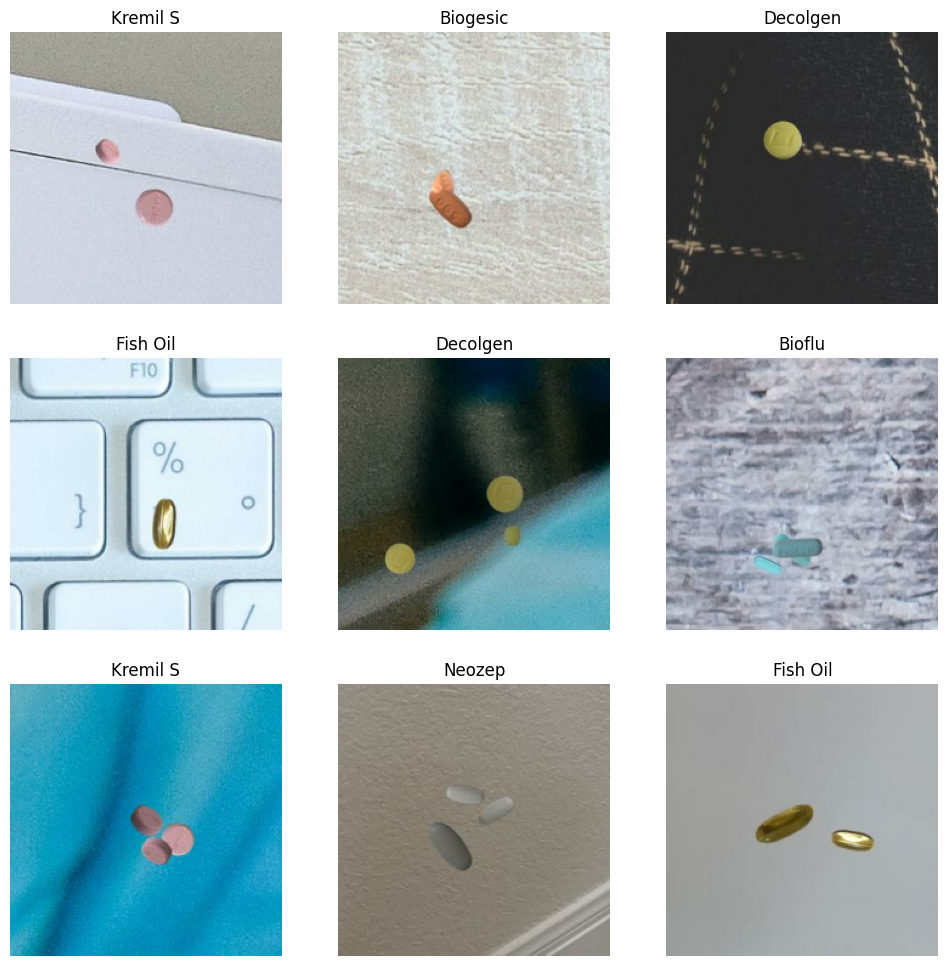

In [ ]:
plt.figure(figsize=(12,12))
for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
print("Training Batches :", len(train_dataset))
print("Validation Batches :", len(validation_dataset))

Training Batches : 250
Validation Batches : 63


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),],
    name="data_augmentation")

In [ ]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3))
base_model.trainable = False
print("EfficientNetB0 Loaded Successfully")

EfficientNetB0 Loaded Successfully


In [ ]:
inputs = tf.keras.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names),activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,380,077 (16.71 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
print("Output Shape :", model.output_shape)
print("Number of Classes :", len(class_names))

Output Shape : (None, 10)
Number of Classes : 10


In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [ ]:
checkpoint = ModelCheckpoint("best_pill_model.keras",monitor="val_accuracy",save_best_only=True,mode="max",verbose=1)
early_stop = EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True,verbose=1)

In [ ]:
history = model.fit(train_dataset,validation_data=validation_dataset,epochs=20,callbacks=[checkpoint, early_stop])

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.2458 - loss: 2.1274
Epoch 1: val_accuracy improved from None to 0.72800, saving model to best_pill_model.keras

Epoch 1: finished saving model to best_pill_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 42s 109ms/step - accuracy: 0.3792 - loss: 1.8690 - val_accuracy: 0.7280 - val_loss: 1.1813
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.6290 - loss: 1.2683
Epoch 2: val_accuracy improved from 0.72800 to 0.79250, saving model to best_pill_model.keras

Epoch 2: finished saving model to best_pill_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 92ms/step - accuracy: 0.6513 - loss: 1.1625 - val_accuracy: 0.7925 - val_loss: 0.7646
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7078 - loss: 0.9488
Epoch 3: val_accuracy improved from 0.79250 to 0.81600, saving model to best_pill_model.keras

Epoch 3: finished saving model to best_pill_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 24s 94ms/step - accur

In [ ]:
model.save("pill_identification_model.keras")
print("Model Saved Successfully")
print(history.history.keys())

Model Saved Successfully
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


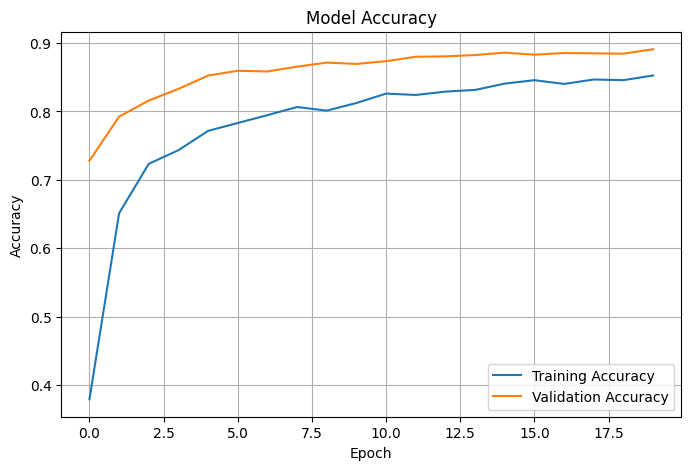

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
loss, accuracy = model.evaluate(validation_dataset)
print("="*40)
print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy*100,"%")
print("="*40)

63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.8910 - loss: 0.3229
Validation Loss : 0.3229030668735504
Validation Accuracy : 89.0999972820282 %


In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

In [ ]:
y_true = []
y_pred = []
for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [ ]:
print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

      Alaxan       0.89      0.92      0.90       202
    Bactidol       0.93      0.88      0.90       198
      Bioflu       0.87      0.87      0.87       189
    Biogesic       0.84      0.84      0.84       194
     DayZinc       0.85      0.92      0.88       197
    Decolgen       0.95      0.92      0.93       200
    Fish Oil       0.91      0.94      0.93       200
    Kremil S       0.91      0.91      0.91       219
     Medicol       0.95      0.95      0.95       201
      Neozep       0.83      0.76      0.79       200

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000



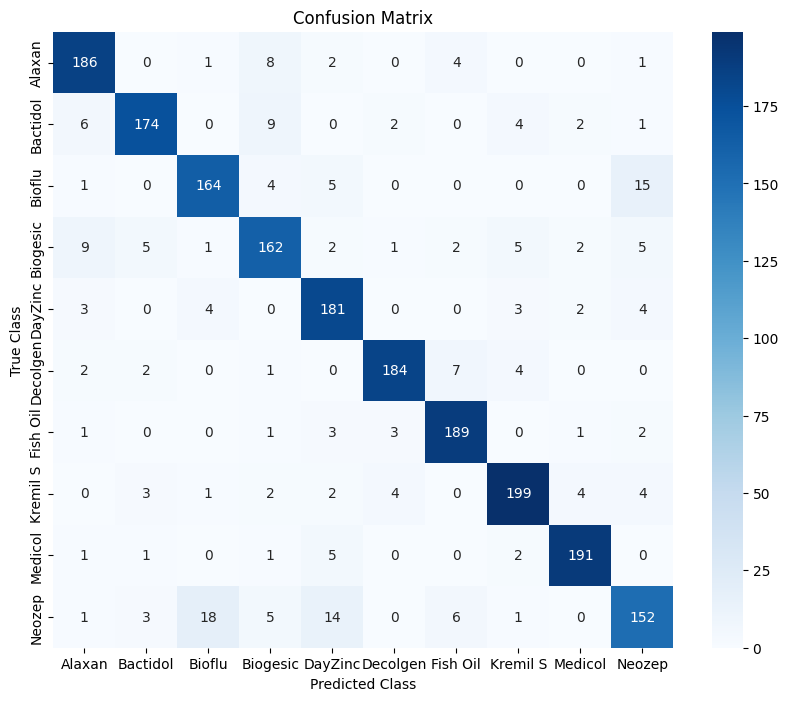

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
model.save("pill_identification_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model("pill_identification_model.keras")
print("Model Loaded Successfully")

Model Loaded Successfully


Saving Prozac-pills.webp to Prozac-pills (1).webp


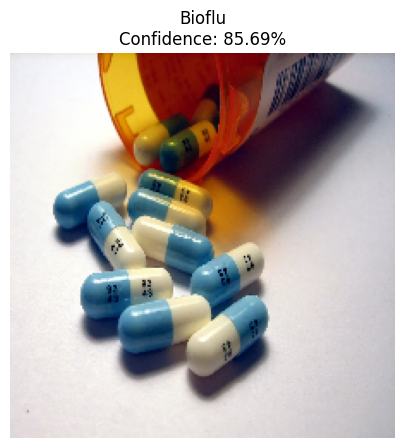

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
uploaded = files.upload()
for filename in uploaded.keys():
    img = image.load_img(filename, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    prediction = model.predict(img_array, verbose=0)
    predicted = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)
    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.title(f"{predicted}\nConfidence: {confidence*100:.2f}%")
    plt.axis("off")
    plt.show()

In [ ]:
prediction = model.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction)
print("Predicted Medicine :", predicted_class)
print("Confidence :", round(confidence*100,2),"%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Predicted Medicine : Bioflu
Confidence : 85.69 %


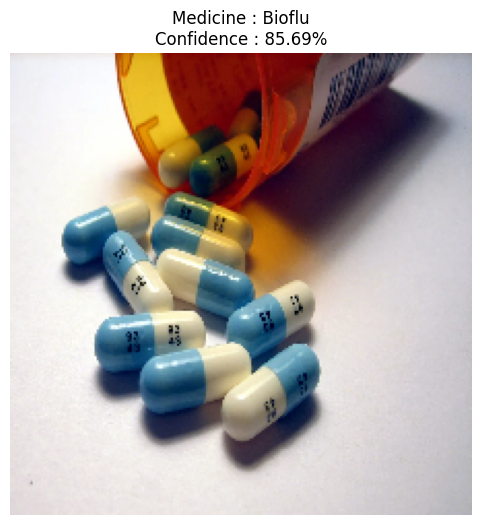

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Medicine : {predicted_class}\nConfidence : {confidence*100:.2f}%")
plt.axis("off")
plt.show()

In [ ]:
loss, accuracy = model.evaluate(validation_dataset)
print(f"Accuracy : {accuracy*100:.2f}%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 71ms/step - accuracy: 0.8910 - loss: 0.3229
Accuracy : 89.10%


In [ ]:
import pickle
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)
print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl
